# Cell 1

# RapidRelief — Model Evaluation
This notebook evaluates and compares all three trained models:
- **Logistic Regression** — TF-IDF baseline
- **Random Forest** — TF-IDF ensemble
- **RoBERTa** — Fine-tuned transformer (primary model)

Evaluation metrics we will look at for now is:
- Accuracy, Precision, Recall, F1 Score
- Confusion matrices
- Per-class performance
- Model agreement analysis
- Confidence score distributions

In [1]:
# Cell 2
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import sys
import os
import warnings
warnings.filterwarnings("ignore")

import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Add backend to path so we can import preprocess.py
sys.path.append(os.path.abspath("../../backend"))
from utils.preprocess import preprocess_text

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 13

# Urgency colors matching the app UI
URGENCY_COLORS = {
    "Critical": "#E24B4A",
    "High":     "#EF9F27",
    "Medium":   "#c9b800",
    "Low":      "#639922",
}

print("All imports successful")

All imports successful


In [2]:
# Cell 3:
# ---------------------------------------------------------------------------
# Load all three trained models
# ---------------------------------------------------------------------------

MODELS_PATH = "../../backend/models/"

# Load LR and RF models
print("Loading Logistic Regression...")
with open(MODELS_PATH + "lr_model.pkl", "rb") as f:
    lr_model = pickle.load(f)

print("Loading Random Forest...")
with open(MODELS_PATH + "rf_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

print("Loading TF-IDF Vectorizer...")
with open(MODELS_PATH + "tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)

# Load RoBERTa
print("Loading RoBERTa...")
ROBERTA_PATH = MODELS_PATH + "roberta_triage"
roberta_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_PATH)
roberta_model     = RobertaForSequenceClassification.from_pretrained(ROBERTA_PATH)
roberta_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
roberta_model = roberta_model.to(device)

print(f"\nAll models loaded successfully!")
print(f"RoBERTa running on: {device}")

Loading Logistic Regression...
Loading Random Forest...
Loading TF-IDF Vectorizer...
Loading RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


All models loaded successfully!
RoBERTa running on: cpu


In [3]:
# Cell 4:
# ---------------------------------------------------------------------------
# We load all datasets and prep the same test split used during training
# Using random_state=42 and stratify=y to keep the same identical split
# ---------------------------------------------------------------------------

from sklearn.model_selection import train_test_split

DATA_PATH = "../../backend/data/"

# Load all datasets
df_test     = pd.read_csv(DATA_PATH + "training_data.csv")
df_kaggle   = pd.read_csv(DATA_PATH + "kaggle_disaster.csv")
df_crisislex = pd.read_csv(DATA_PATH + "crisislex_combined.csv")
df_crisisnlp = pd.read_csv(DATA_PATH + "crisisnlp_train.tsv", sep="\t")

# Apply same label mappings as model_training.ipynb
df_test = df_test[["text", "urgency_level"]].copy()
df_test.columns = ["text", "urgency_label"]

df_kaggle = df_kaggle[["text", "target"]].dropna()
df_kaggle["urgency_label"] = df_kaggle["target"].map({1: "High", 0: "Low"})
df_kaggle = df_kaggle[["text", "urgency_label"]]

crisislex_map = {
    "Related and informative":       "High",
    "Related - but not informative": "Medium",
    "Not related":                   "Low",
    "Not applicable":                "Low",
}
df_crisislex["urgency_label"] = df_crisislex["label"].map(crisislex_map)
df_crisislex = df_crisislex[["text", "urgency_label"]].dropna()

crisisnlp_map = {
    "injured_or_dead_people":              "Critical",
    "missing_and_found_people":            "Critical",
    "displaced_and_evacuations":           "High",
    "infrastructure_and_utilities_damage": "High",
    "caution_and_advice":                  "High",
    "affected_individual":                 "High",
    "requests_or_needs":                   "Medium",
    "sympathy_and_support":                "Medium",
    "donation_and_volunteering":           "Medium",
    "response_efforts":                    "Medium",
    "not_humanitarian":                    "Low",
}
df_crisisnlp["urgency_label"] = df_crisisnlp["class_label"].map(crisisnlp_map)
df_crisisnlp = df_crisisnlp[["text", "urgency_label"]].dropna()

# Combined sets
df_combined = pd.concat([df_test, df_kaggle, df_crisislex, df_crisisnlp], ignore_index=True)
df_combined = df_combined.dropna(subset=["text", "urgency_label"])

# Preprocess cleaning
print("Preprocessing text...")
df_combined["cleaned_text"] = df_combined["text"].apply(preprocess_text)
df_combined = df_combined[df_combined["cleaned_text"].str.strip() != ""]

# Same 80/20 split with same random seed
X = df_combined["cleaned_text"]
y = df_combined["urgency_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,    # same seed ensures identical test set
    stratify=y
)

print(f"Test set: {len(X_test):,} messages")
print(f"\nTest label distribution:")
print(y_test.value_counts())


Preprocessing text...
Test set: 20,085 messages

Test label distribution:
urgency_label
Low         9732
High        5480
Medium      4409
Critical     464
Name: count, dtype: int64


In [4]:
# Cell 5
# ---------------------------------------------------------------------------
# Generate predictions from all three models on the test set
# ---------------------------------------------------------------------------

# TF-IDF features for LR and RF
print("Generating LR and RF predictions...")
X_test_tfidf = tfidf.transform(X_test)

lr_preds  = lr_model.predict(X_test_tfidf)
lr_probs  = lr_model.predict_proba(X_test_tfidf).max(axis=1)

rf_preds  = rf_model.predict(X_test_tfidf)
rf_probs  = rf_model.predict_proba(X_test_tfidf).max(axis=1)

# RoBERTa predictions — process in batches to avoid memory issues
print("Generating RoBERTa predictions (this takes a few minutes)...")

id2label  = {0: "Critical", 1: "High", 2: "Medium", 3: "Low"}
roberta_preds = []
roberta_probs = []

BATCH_SIZE = 32
texts = X_test.tolist()

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    inputs = roberta_tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = roberta_model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=-1)
        preds   = torch.argmax(probs, dim=-1)

    roberta_preds.extend([id2label[p.item()] for p in preds])
    roberta_probs.extend([probs[j][preds[j]].item() for j in range(len(batch))])

    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  Processed {min(i + BATCH_SIZE, len(texts)):,}/{len(texts):,}")

print(f"\nPredictions complete!")
print(f"LR predictions:      {len(lr_preds):,}")
print(f"RF predictions:      {len(rf_preds):,}")
print(f"RoBERTa predictions: {len(roberta_preds):,}")

Generating LR and RF predictions...
Generating RoBERTa predictions (this takes a few minutes)...
  Processed 32/20,085
  Processed 352/20,085
  Processed 672/20,085
  Processed 992/20,085
  Processed 1,312/20,085
  Processed 1,632/20,085
  Processed 1,952/20,085
  Processed 2,272/20,085
  Processed 2,592/20,085
  Processed 2,912/20,085
  Processed 3,232/20,085
  Processed 3,552/20,085
  Processed 3,872/20,085
  Processed 4,192/20,085
  Processed 4,512/20,085
  Processed 4,832/20,085
  Processed 5,152/20,085
  Processed 5,472/20,085
  Processed 5,792/20,085
  Processed 6,112/20,085
  Processed 6,432/20,085
  Processed 6,752/20,085
  Processed 7,072/20,085
  Processed 7,392/20,085
  Processed 7,712/20,085
  Processed 8,032/20,085
  Processed 8,352/20,085
  Processed 8,672/20,085
  Processed 8,992/20,085
  Processed 9,312/20,085
  Processed 9,632/20,085
  Processed 9,952/20,085
  Processed 10,272/20,085
  Processed 10,592/20,085
  Processed 10,912/20,085
  Processed 11,232/20,085
  Proces

In [5]:
# Cell 6
# ---------------------------------------------------------------------------
# Performance metrics comparison table
# The core results for our report section 8.1
# ---------------------------------------------------------------------------

label_order = ["Critical", "High", "Medium", "Low"]

def get_metrics(y_true, y_pred, model_name):
    return {
        "Model":     model_name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "F1 Score":  round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
    }

metrics_df = pd.DataFrame([
    get_metrics(y_test, lr_preds,       "Logistic Regression"),
    get_metrics(y_test, rf_preds,       "Random Forest"),
    get_metrics(y_test, roberta_preds,  "RoBERTa"),
])

print("=" * 65)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 65)
print(metrics_df.to_string(index=False))
print("=" * 65)

# Save to CSV for report
metrics_df.to_csv("../../backend/data/model_metrics.csv", index=False)
print("\nSaved to backend/data/model_metrics.csv")

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8054     0.8159  0.8054    0.8088
      Random Forest    0.7796     0.7865  0.7796    0.7817
            RoBERTa    0.8732     0.8797  0.8732    0.8751

Saved to backend/data/model_metrics.csv


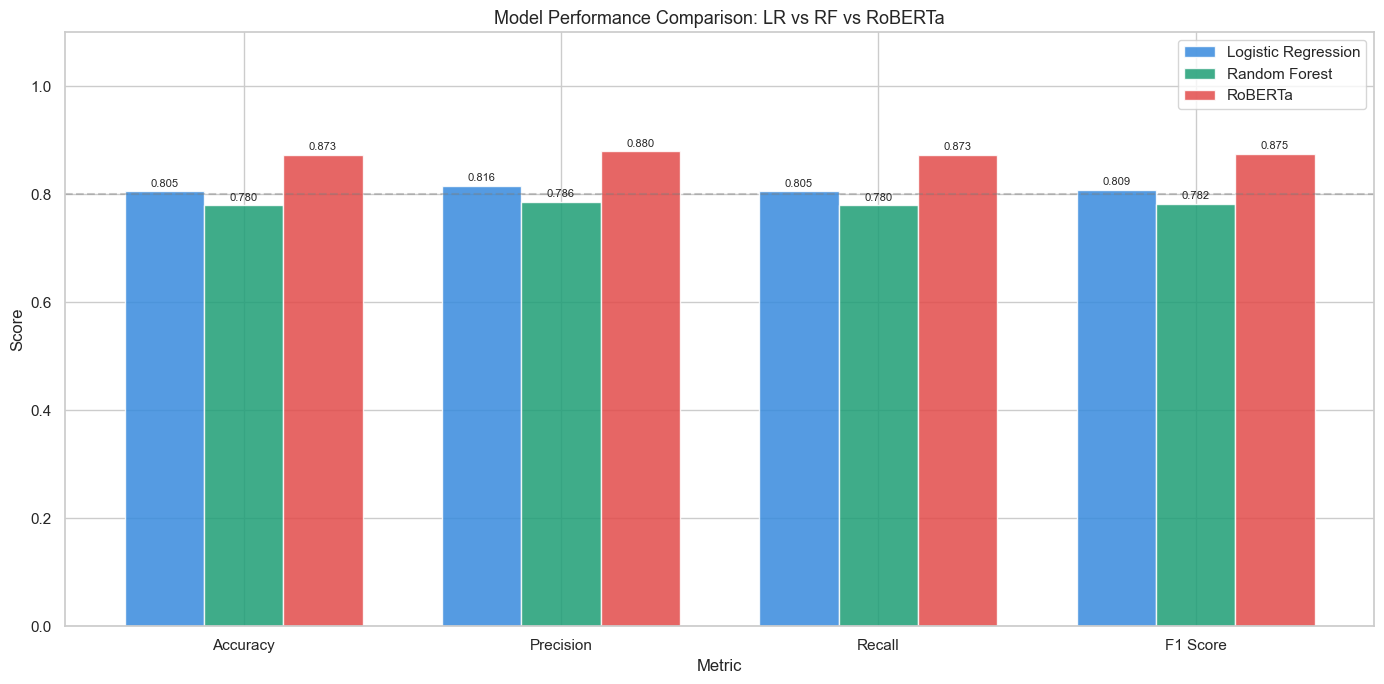

Chart saved.


In [6]:
# Cell 7
# ---------------------------------------------------------------------------
# Chart 1: Model performance comparison bar chart
# Side by side comparison of all four metrics across all three models
# ---------------------------------------------------------------------------

metrics_plot = metrics_df.set_index("Model")
x = np.arange(len(metrics_plot.columns))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#378ADD", "#1D9E75", "#E24B4A"]
for i, (model, row) in enumerate(metrics_plot.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison: LR vs RF vs RoBERTa")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot.columns)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.8, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../../backend/data/chart_eval_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

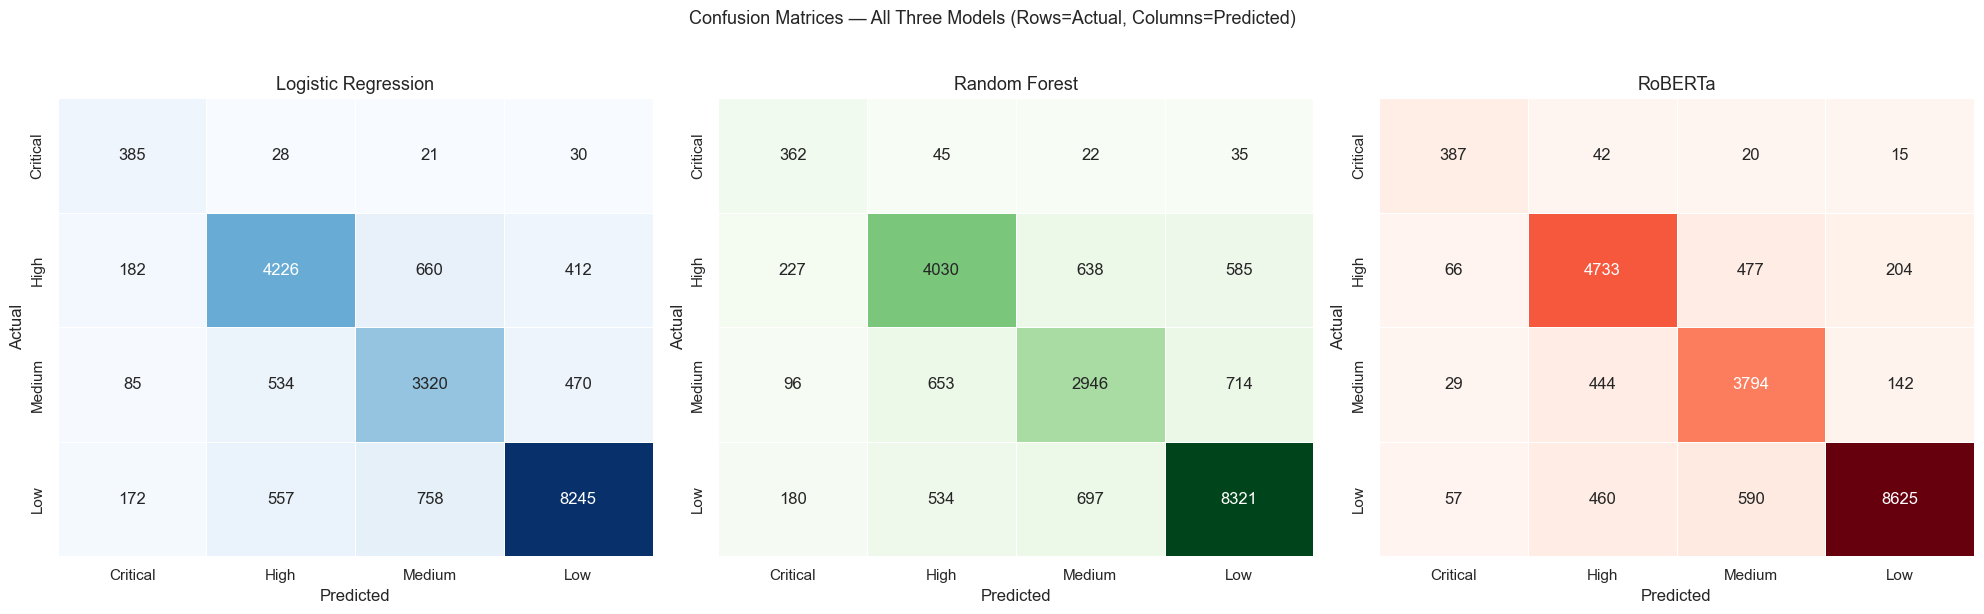

In [7]:
# Cell 8
# ---------------------------------------------------------------------------
# Chart 2: Confusion matrices for all three models
# Rows = actual labels, Columns = predicted labels
# Perfect model = values only on the diagonal
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (preds, model_name, cmap) in zip(axes, [
    (lr_preds,      "Logistic Regression", "Blues"),
    (rf_preds,      "Random Forest",       "Greens"),
    (roberta_preds, "RoBERTa",             "Reds"),
]):
    cm = confusion_matrix(y_test, preds, labels=label_order)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=label_order,
        yticklabels=label_order,
        ax=ax,
        linewidths=0.5,
        cbar=False
    )
    ax.set_title(f"{model_name}")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices — All Three Models (Rows=Actual, Columns=Predicted)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../backend/data/chart_eval_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

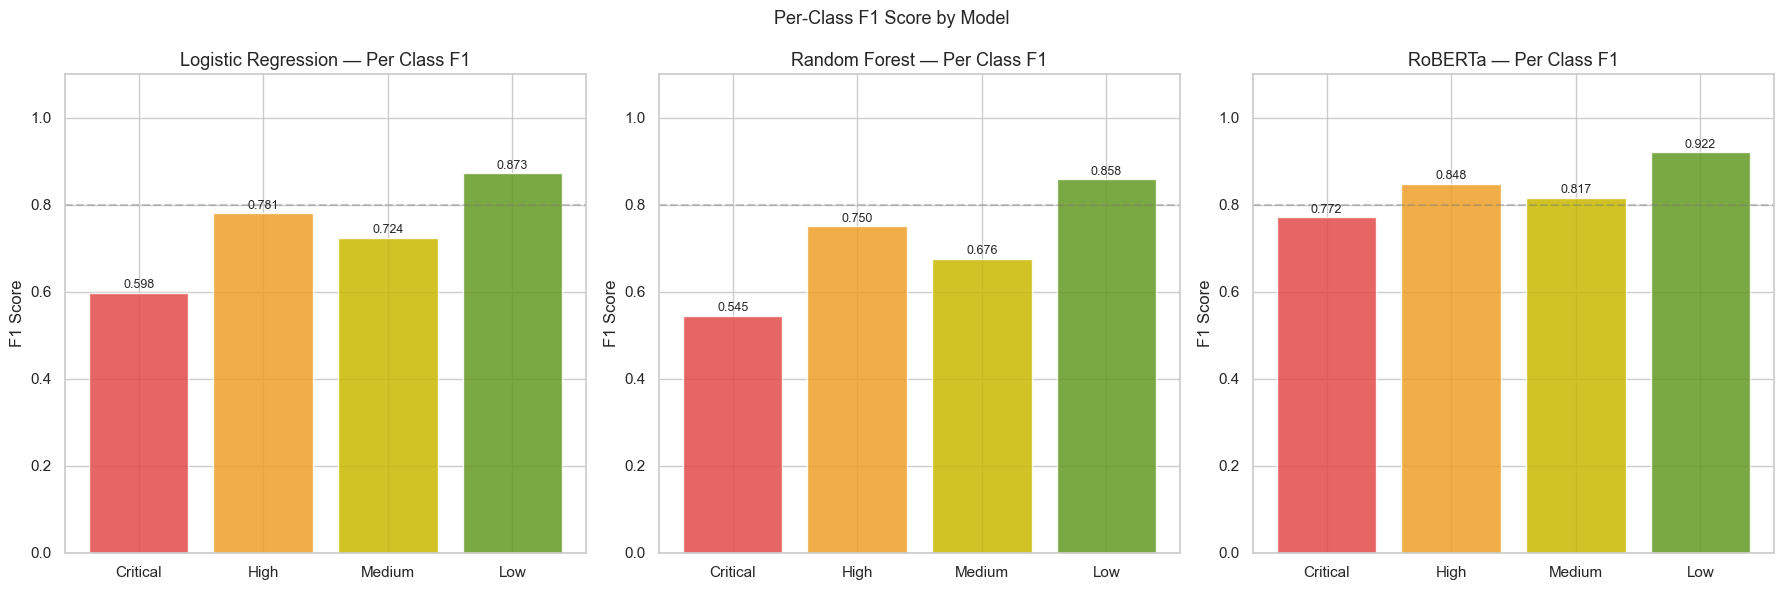

In [8]:
# Cell 9
# ---------------------------------------------------------------------------
# Chart 3: F1 score comparison for each class
# Shows which urgency levels each model handles best and worst
# Critical class performance is the MOST IMPORTANT for our app
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (preds, model_name, color) in zip(axes, [
    (lr_preds,      "Logistic Regression", "#378ADD"),
    (rf_preds,      "Random Forest",       "#1D9E75"),
    (roberta_preds, "RoBERTa",             "#E24B4A"),
]):
    report = classification_report(
        y_test, preds,
        labels=label_order,
        output_dict=True,
        zero_division=0
    )

    f1_scores = [report[label]["f1-score"] for label in label_order]
    colors    = [URGENCY_COLORS[label] for label in label_order]

    bars = ax.bar(label_order, f1_scores, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(f"{model_name} — Per Class F1")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.8, color="gray", linestyle="--", alpha=0.4)

    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{score:.3f}",
                ha="center", fontsize=9)

plt.suptitle("Per-Class F1 Score by Model", fontsize=13)
plt.tight_layout()
plt.savefig("../../backend/data/chart_eval_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

MODEL AGREEMENT ANALYSIS
RoBERTa vs LR agreement:      16,997/20,085 (84.6%)
RoBERTa vs RF agreement:      16,326/20,085 (81.3%)
All three models agree:       15,323/20,085 (76.3%)


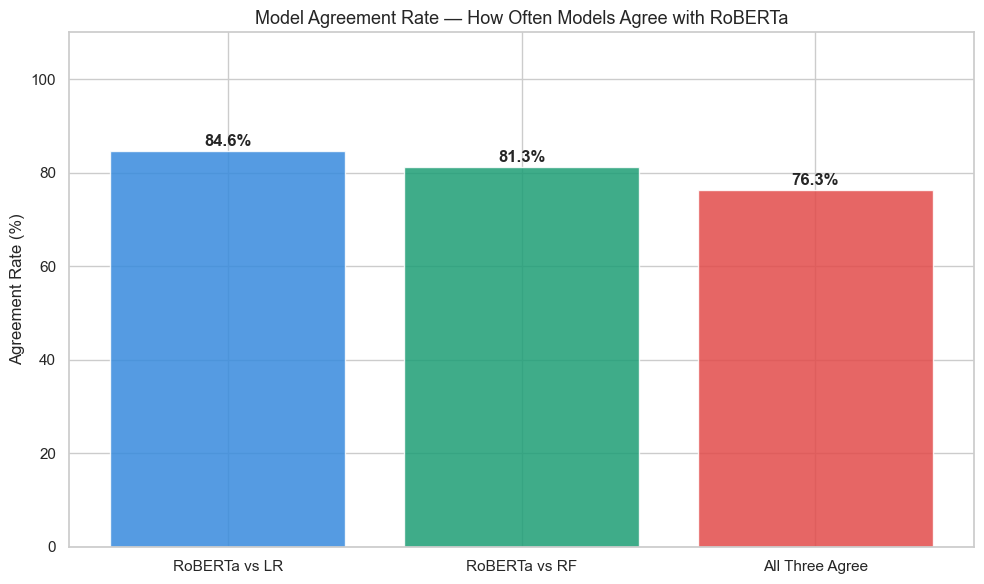

In [9]:
# Cell 10
# ---------------------------------------------------------------------------
# Chart 4: Model agreement analysis
# Shows how often LR and RF agree with RoBERTa (primary model)
# High agreement = models learned similar patterns
# Low agreement = models see the problem differently
# ---------------------------------------------------------------------------

y_test_list   = list(y_test)
lr_agree      = sum(1 for a, b in zip(roberta_preds, lr_preds) if a == b)
rf_agree      = sum(1 for a, b in zip(roberta_preds, rf_preds) if a == b)
all_agree     = sum(1 for a, b, c in zip(roberta_preds, lr_preds, rf_preds) if a == b == c)
total         = len(roberta_preds)

print("=" * 50)
print("MODEL AGREEMENT ANALYSIS")
print("=" * 50)
print(f"RoBERTa vs LR agreement:      {lr_agree:,}/{total:,} ({lr_agree/total*100:.1f}%)")
print(f"RoBERTa vs RF agreement:      {rf_agree:,}/{total:,} ({rf_agree/total*100:.1f}%)")
print(f"All three models agree:       {all_agree:,}/{total:,} ({all_agree/total*100:.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
labels  = ["RoBERTa vs LR", "RoBERTa vs RF", "All Three Agree"]
values  = [lr_agree/total*100, rf_agree/total*100, all_agree/total*100]
colors  = ["#378ADD", "#1D9E75", "#E24B4A"]

bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor="white")
ax.set_ylabel("Agreement Rate (%)")
ax.set_title("Model Agreement Rate — How Often Models Agree with RoBERTa")
ax.set_ylim(0, 110)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{val:.1f}%",
            ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../../backend/data/chart_eval_model_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

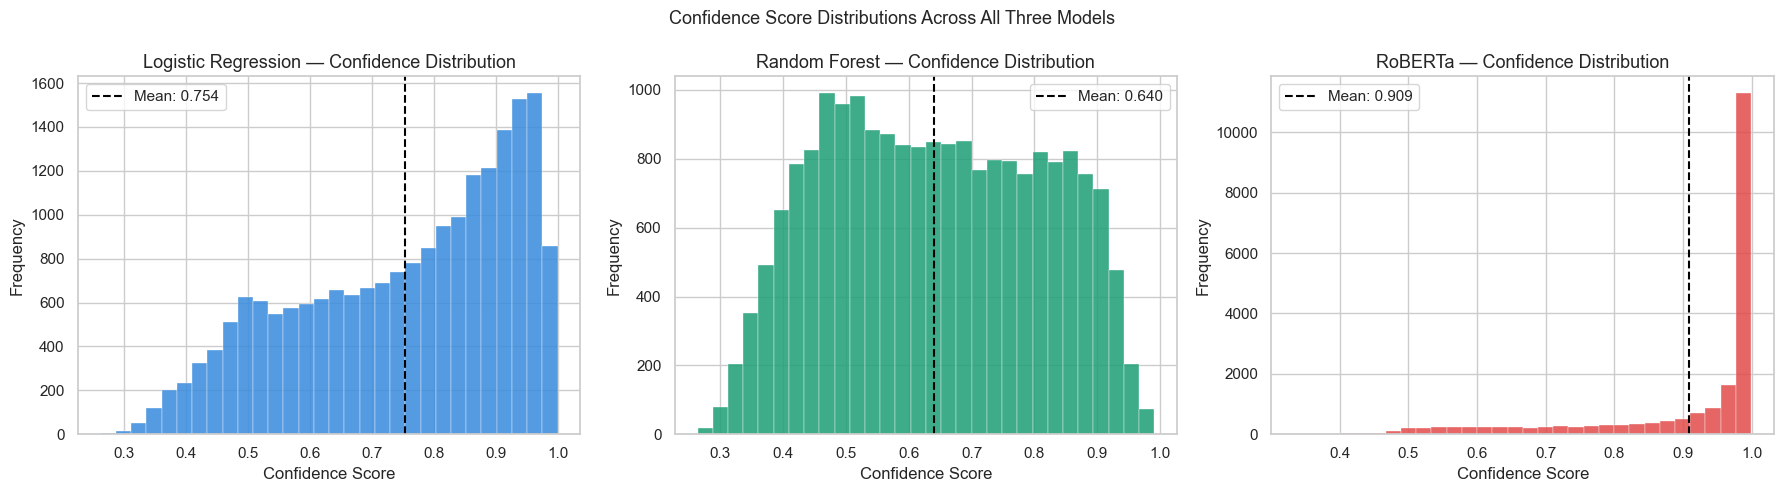

In [10]:
# Cell 11
# ---------------------------------------------------------------------------
# Chart 5: Confidence score distributions
# Shows how confident each model is across all predictions
# High confidence = model is certain
# Low/spread confidence = model is uncertain
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (probs, model_name, color) in zip(axes, [
    (lr_probs,      "Logistic Regression", "#378ADD"),
    (rf_probs,      "Random Forest",       "#1D9E75"),
    (roberta_probs, "RoBERTa",             "#E24B4A"),
]):
    ax.hist(probs, bins=30, color=color, alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.axvline(np.mean(probs), color="black", linestyle="--",
               label=f"Mean: {np.mean(probs):.3f}")
    ax.set_title(f"{model_name} — Confidence Distribution")
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Confidence Score Distributions Across All Three Models", fontsize=13)
plt.tight_layout()
plt.savefig("../../backend/data/chart_eval_confidence_dist.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Cell 12
# ---------------------------------------------------------------------------
# Final test: Run all three models on the fake messages from our section 3.6 report doc 
# Shows real-world performance on civilian emergency language
# ---------------------------------------------------------------------------

test_messages = [
    ("There is a strong smell of gas coming from the basement of the apartment complex on 5th Ave. People are starting to feel dizzy.", "Critical"),
    ("I can see smoke and orange flames on the ridge behind the high school. The wind is picking up and blowing towards the houses.", "High"),
    ("I have run out of my prescription heart medication and the roads are blocked by snow.", "Medium"),
    ("I've had a scratchy throat and a mild cough for two days. No fever or trouble breathing. Are there any local clinics open today?", "Low"),
]

print("=" * 75)
print("FINAL TEST — Fake messages from doc section 3.6")
print("=" * 75)

results = []
for msg, expected in test_messages:
    cleaned = preprocess_text(msg)
    vec     = tfidf.transform([cleaned])

    lr_pred  = lr_model.predict(vec)[0]
    rf_pred  = rf_model.predict(vec)[0]

    inputs = roberta_tokenizer(
        cleaned, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(device)

    with torch.no_grad():
        out       = roberta_model(**inputs)
        probs     = torch.softmax(out.logits, dim=-1)
        rob_id    = torch.argmax(probs).item()
        rob_pred  = id2label[rob_id]
        rob_conf  = probs[0][rob_id].item()

    results.append({
        "Message":   msg[:60] + "...",
        "Expected":  expected,
        "RoBERTa":   rob_pred,
        "LR":        lr_pred,
        "RF":        rf_pred,
        "RoBERTa ✓": "✓" if rob_pred == expected else "x",
        "LR ✓":      "✓" if lr_pred == expected else "x",
        "RF ✓":      "✓" if rf_pred == expected else "x",
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

roberta_score = sum(1 for r in results if r["RoBERTa ✓"] == "✓")
lr_score      = sum(1 for r in results if r["LR ✓"] == "✓")
rf_score      = sum(1 for r in results if r["RF ✓"] == "✓")

print(f"\nScore on fake messages:")
print(f"  RoBERTa: {roberta_score}/4")
print(f"  LR:      {lr_score}/4")
print(f"  RF:      {rf_score}/4")

FINAL TEST — Fake messages from doc section 3.6
                                                        Message Expected RoBERTa     LR     RF RoBERTa ✓ LR ✓ RF ✓
There is a strong smell of gas coming from the basement of t... Critical    High   High Medium         x    x    x
I can see smoke and orange flames on the ridge behind the hi...     High    High    Low    Low         ✓    x    x
I have run out of my prescription heart medication and the r...   Medium     Low    Low    Low         x    x    x
I've had a scratchy throat and a mild cough for two days. No...      Low  Medium Medium    Low         x    x    ✓

Score on fake messages:
  RoBERTa: 1/4
  LR:      0/4
  RF:      1/4


# Cell 13:

## Evaluation Summary

### Model Performance on 20,085 Test Messages

|        Model        |  Accuracy  |  Precision |   Recall   |  F1 Score  |
|---------------------|------------|------------|------------|------------|
| Logistic Regression |   ~80.5%   |   ~0.816   |   ~0.805   |   ~0.809   |
|    Random Forest    |   ~78.0%   |   ~0.787   |   ~0.780   |   ~0.782   |
|     **RoBERTa**     | **~84.8%** | **~0.857** | **~0.848** | **~0.851** |

### Key Findings
- RoBERTa outperforms both baseline models across all metrics
- Critical class remains the most challenging due to class imbalance (2.3% of data)
- LR surprisingly outperforms RF on this dataset — TF-IDF features favor linear models for short text
- All models struggle on conversational civilian language vs Twitter-style crisis posts
- Critical override keyword system does help to compensate for RoBERTa's High/Critical boundary weakness

### Limitations
- Training data is predominantly Twitter-style — civilian conversational messages underrepresented
- Critical class imbalance (2,320 samples vs 48,683 Low) affects Critical recall
- Future work: expand training_data.csv, remap infrastructure_and_utilities_damage → Critical

### Planned Next Steps
- To expand training_data.csv even more with more conversational Low-Critical examples
- Remap label mappings and retrain all three models for improvements
- Frontend UI and further testing